# Notebook 6 — Reporting & Visualization

**Course: Cross-Corridor Capacity Analysis with pandapower (Svedala grid)**

We turn raw sweep results into operator-facing artefacts:

- A **TTC table** (both directions, limiting element).
- **PV-style** curves of voltage and loading vs corridor flow.
- A **map overlay** highlighting the corridor (orange) and limiting element (red).
- A clean **export** of the report to `report/`.

## 6.1  Set up

In [10]:
import pandapower as pp
import pandas as pd
import numpy as np
import json as _json, os
import matplotlib.pyplot as plt

net = pp.from_json('data/svedala_base.json')
pp.runpp(net)

with open('data/corridor.json') as f:
    corridor = _json.load(f)
with open('data/ttc_pos.json') as f:
    ttc = _json.load(f)

sweep_pos = pd.read_csv('data/capacity_sweep_pos.csv')
sweep_neg = pd.read_csv('data/capacity_sweep_neg.csv')

P0 = corridor['base_flow_a_to_b']
ZONE_SOURCE = corridor['zone_source']
ZONE_SINK   = corridor['zone_sink']

## 6.2  Capacity table

In [11]:
def summarise(sweep, label):
    feas = sweep[sweep.feasible]
    last = feas.corridor_flow.iloc[-1] if len(feas) else None
    if 'sink_to_source' in label and last is not None:
        last = -last
    return {'direction': label,
            'TTC_MW': round(last, 1) if last is not None else None}

table = pd.DataFrame([
    summarise(sweep_pos, f'{ZONE_SOURCE}_to_{ZONE_SINK}'),
    summarise(sweep_neg, f'{ZONE_SINK}_to_{ZONE_SOURCE}_sink_to_source'),
])
table['limiting_element_pos'] = f'{ttc["limiting_kind"]} #{ttc["limiting_idx"]}'
table

,direction,TTC_MW,limiting_element_pos
0,ZON_NORR_to_ZON_MITT,3355.1,vlow #971
1,ZON_MITT_to_ZON_NORR_sink_to_source,-2422.3,vlow #971


## 6.3  PV-style curves

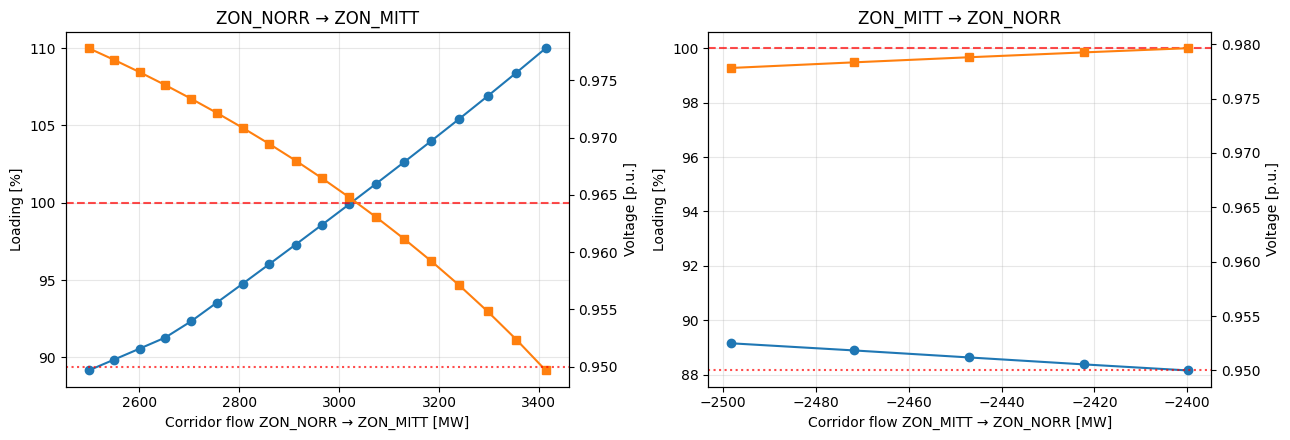

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, sw, lbl in [
    (axes[0], sweep_pos, f'{ZONE_SOURCE} → {ZONE_SINK}'),
    (axes[1], sweep_neg, f'{ZONE_SINK} → {ZONE_SOURCE}'),
]:
    x = sw.corridor_flow if sw is sweep_pos else -sw.corridor_flow
    ax.plot(x, sw.max_line_loading, 'o-', color='C0', label='max line loading [%]')
    ax.axhline(100, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel(f'Corridor flow {lbl} [MW]')
    ax.set_ylabel('Loading [%]')
    ax2 = ax.twinx()
    ax2.plot(x, sw.min_voltage, 's-', color='C1', label='min voltage [p.u.]')
    ax2.axhline(0.95, color='red', linestyle=':', alpha=0.7)
    ax2.set_ylabel('Voltage [p.u.]')
    ax.set_title(lbl)
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6.4  Map overlay — corridor + limiting element on Svedala geography

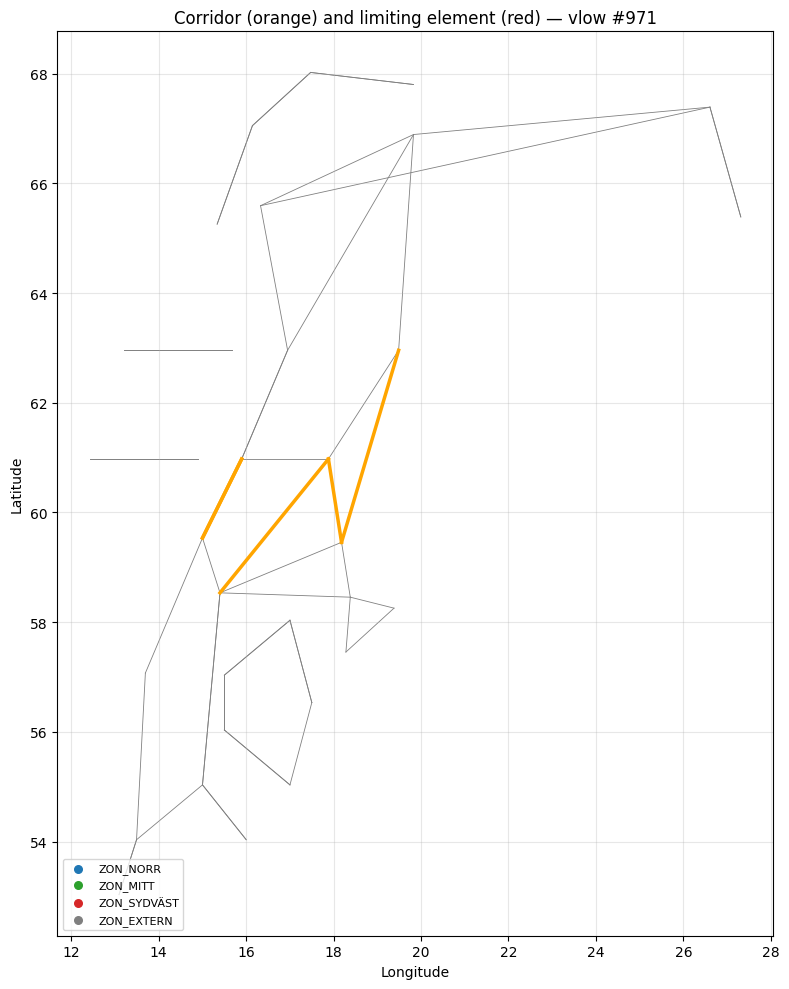

In [13]:
def coords(geo_str):
    if pd.isna(geo_str): return (None, None)
    lon, lat = _json.loads(geo_str)['coordinates']
    return lon, lat

lon = net.bus.geo.apply(lambda g: coords(g)[0])
lat = net.bus.geo.apply(lambda g: coords(g)[1])

ZONE_COLOR = {'ZON_NORR':'#1f77b4','ZON_MITT':'#2ca02c',
              'ZON_SYDVÄST':'#d62728','ZON_EXTERN':'#7f7f7f'}

corridor_line_idx = [i for i, _ in corridor['corridor_lines']]
limiting_idx = ttc['limiting_idx']
limiting_is_line = (ttc['limiting_kind'] == 'line')

fig, ax = plt.subplots(figsize=(8, 10))
for zone, color in ZONE_COLOR.items():
    sub = net.bus[net.bus.zone == zone]
    ax.scatter(lon[sub.index], lat[sub.index], c=color,
               label=zone, s=30, zorder=3)
for idx, ln in net.line.iterrows():
    fb, tb = ln.from_bus, ln.to_bus
    if limiting_is_line and idx == limiting_idx:
        col, lw, z = 'red', 4.0, 4
    elif idx in corridor_line_idx:
        col, lw, z = 'orange', 2.5, 3
    else:
        col, lw, z = 'gray', 0.6, 1
    ax.plot([lon[fb], lon[tb]], [lat[fb], lat[tb]],
            color=col, linewidth=lw, zorder=z)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Corridor (orange) and limiting element (red) — '
             f'{ttc["limiting_kind"]} #{ttc["limiting_idx"]}')
ax.legend(loc='lower left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6.5  Export the report

In [ ]:
os.makedirs('report', exist_ok=True)
summary = {
    'corridor':         f'{ZONE_SOURCE} ↔ {ZONE_SINK}',
    'base_flow_mw':     round(P0, 2),
    'ttc_pos_mw':       round(ttc['ttc_flow_mw'], 2) if ttc['ttc_flow_mw'] else None,
    'limiting_element': f'{ttc["limiting_kind"]} #{ttc["limiting_idx"]}',
    'note':             'NTC = TTC - TRM. TRM not computed here; '
                        'see the combined assignment for N-1 secure TTC.',
}
with open('report/capacity_summary.json', 'w') as f:
    _json.dump(summary, f, indent=2, ensure_ascii=False)
sweep_pos.to_csv('report/capacity_sweep_pos.csv', index=False)
sweep_neg.to_csv('report/capacity_sweep_neg.csv', index=False)
table.to_csv('report/capacity_table.csv', index=False)

lines = ['# Capacity Report — Svedala', '',
         f'**Corridor:** {ZONE_SOURCE} ↔ {ZONE_SINK}', '',
         f'**Base flow:** {P0:+.2f} MW', '',
         '## Total Transfer Capacity', '',
         table.to_markdown(index=False), '',
         f'**Limiting element ({ZONE_SOURCE} → {ZONE_SINK}):** '
         f'`{summary["limiting_element"]}`', '',
         '## Note on NTC', summary['note']]
with open('report/capacity_report.md', 'w') as f:
    f.write('\n'.join(lines))
print('Report written to report/')

---

🎓 **Course complete.**